In [158]:
import pandas as pd
import torchvision.transforms as T
from PIL import Image
import torch
import torch.nn as nn
import easyocr
import cv2

In [159]:
NUM_EPOCHS = 30
TRAIN_DATA = "/Users/pashantraj/Desktop/Repos/Computer_vision/CRNN/traindata.csv"
TEST_DATA = "/Users/pashantraj/Desktop/Repos/Computer_vision/CRNN/testdata.csv"

In [160]:
train_df = pd.read_csv(TRAIN_DATA)
test_df  = pd.read_csv(TEST_DATA)
full_df = pd.concat([train_df, test_df], ignore_index=True)

In [161]:
chars = sorted(set("".join(full_df["GroundTruth"].astype(str))))
char_to_idx = {c: i + 1 for i, c in enumerate(chars)}
idx_to_char = {i + 1: c for i, c in enumerate(chars)}
BLANK_IDX   = 0
NUM_CLASSES = len(chars) + 1
print("Vocab size (incl. blank):", NUM_CLASSES)

Vocab size (incl. blank): 37


In [162]:
val_transform = T.Compose([
    T.Resize((32, 256)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

In [163]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            # Layer 1: 32x256 -> 16x128
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Layer 2: 16x128 -> 8x64
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Layer 3: 8x64 -> 8x64
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Layer 4: 8x64 -> 8x64
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Squash height from 8 down to 1 while preserving 64 horizontal time steps
            nn.MaxPool2d(kernel_size=(8, 1)) 
        )
        self.rnn = nn.LSTM(
            input_size=256, hidden_size=256,
            num_layers=2, bidirectional=True, batch_first=False,dropout=0.5
        )
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)          # Output shape: (B, 256, 1, 64)
        x = x.squeeze(2)         # Output shape: (B, 256, 64)
        x = x.permute(2, 0, 1)   # Output shape: (64, B, 256) -> Time-first for LSTM
        x, _ = self.rnn(x)       # Output shape: (64, B, 512)
        x = self.fc(x)           # Output shape: (64, B, num_classes)
        return x

In [164]:
class DBPostProcess:
    def __init__(self, prob_threshold=0.3, unclip_ratio=1.5, min_area=16):
        """
        prob_threshold: The threshold to binarize the probability map.
        unclip_ratio: How much to expand the detected box (inverse of shrink_ratio).
        min_area: Ignore boxes smaller than this many pixels.
        """
        self.prob_threshold = prob_threshold
        self.unclip_ratio = unclip_ratio
        self.min_area = min_area

    def __call__(self, prob_map, orig_shape, target_shape):
        """
        prob_map: Tensor of shape (1, H, W) directly from the model output.
        orig_shape: (H, W) of the original unscaled image.
        target_shape: (H, W) of the image size passed to the network.
        """
        # 1. Binarize the probability map
        prob_map = prob_map.squeeze().cpu().numpy()
        segmentation = prob_map > self.prob_threshold
        
        # 2. Find contours of the text blobs
        mask = (segmentation * 255).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
        
        boxes = []
        for contour in contours:
            # 3. Fit a bounding polygon and check minimum area
            poly = cv2.approxPolyDP(contour, epsilon=0.005 * cv2.arcLength(contour, True), closed=True)
            if len(poly) < 4:
                rect = cv2.minAreaRect(contour)
                poly = cv2.boxPoints(rect)
            else:
                poly = poly.reshape(-1, 2)
                
            polygon_shape = Polygon(poly)
            if polygon_shape.area < self.min_area:
                continue
                
            # 4. Unclip (Expand) the polygon to its true boundary size
            distance = polygon_shape.area * self.unclip_ratio / (polygon_shape.length + 1e-5)
            offset = pyclipper.PyclipperOffset()
            offset.AddPath(poly.astype(np.int32), pyclipper.JT_ROUND, pyclipper.ET_CLOSEDPOLYGON)
            expanded = offset.Execute(distance)
            
            if len(expanded) == 0:
                continue
            
            # Get the exact 4-point bounding box of the expanded area
            expanded_poly = np.array(expanded[0])
            rect = cv2.minAreaRect(expanded_poly)
            box = cv2.boxPoints(rect)
            
            # 5. Scale coordinates back to the original image dimensions
            scale_x = orig_shape[1] / target_shape[1]
            scale_y = orig_shape[0] / target_shape[0]
            
            box[:, 0] = np.clip(box[:, 0] * scale_x, 0, orig_shape[1] - 1)
            box[:, 1] = np.clip(box[:, 1] * scale_y, 0, orig_shape[0] - 1)
            
            # Order the points strictly: Top-Left, Top-Right, Bottom-Right, Bottom-Left
            box = self.order_points_clockwise(box)
            boxes.append(box.astype(np.int32))
            
        return boxes

    def order_points_clockwise(self, pts):
        """Sorts the 4 points in a consistent Top-Left to Bottom-Left order."""
        rect = np.zeros((4, 2), dtype=np.float32)
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]
        rect[2] = pts[np.argmax(s)]
        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]
        rect[3] = pts[np.argmax(diff)]
        return rect






class DifferentiableBinarization(nn.Module):
    def __init__(self, k=50):
        super().__init__()
        self.k = k

    def forward(self, prob_map, thresh_map):
        return torch.reciprocal(1.0 + torch.exp(-self.k * (prob_map - thresh_map)))



class ResNet18Backbone(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()

        if pretrained:
            resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        else:
            resnet = models.resnet18(weights=None)
            
       
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1  # Output: 1/4 resolution, 64 channels
        self.layer2 = resnet.layer2  # Output: 1/8 resolution, 128 channels
        self.layer3 = resnet.layer3  # Output: 1/16 resolution, 256 channels
        self.layer4 = resnet.layer4  # Output: 1/32 resolution, 512 channels

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        
        c2 = self.layer1(x)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        
        return c2, c3, c4, c5



class DBNetFPN(nn.Module):
    def __init__(self, in_channels=[64, 128, 256, 512], inner_channels=256):
        super().__init__()
        
        self.reduce_c5 = nn.Conv2d(in_channels[3], inner_channels, kernel_size=1, bias=False)
        self.reduce_c4 = nn.Conv2d(in_channels[2], inner_channels, kernel_size=1, bias=False)
        self.reduce_c3 = nn.Conv2d(in_channels[1], inner_channels, kernel_size=1, bias=False)
        self.reduce_c2 = nn.Conv2d(in_channels[0], inner_channels, kernel_size=1, bias=False)
        
        self.smooth_p4 = nn.Conv2d(inner_channels, inner_channels // 4, kernel_size=3, padding=1, bias=False)
        self.smooth_p3 = nn.Conv2d(inner_channels, inner_channels // 4, kernel_size=3, padding=1, bias=False)
        self.smooth_p2 = nn.Conv2d(inner_channels, inner_channels // 4, kernel_size=3, padding=1, bias=False)
        self.smooth_p5 = nn.Conv2d(inner_channels, inner_channels // 4, kernel_size=3, padding=1, bias=False)

    def forward(self, features):
        c2, c3, c4, c5 = features
        
        p5 = self.reduce_c5(c5)
        
        # FIX 1: Explicitly target the spatial sizes of the C-layers instead of using scale_factor=2
        p4 = self.reduce_c4(c4) + F.interpolate(p5, size=c4.shape[2:], mode='nearest')
        p3 = self.reduce_c3(c3) + F.interpolate(p4, size=c3.shape[2:], mode='nearest')
        p2 = self.reduce_c2(c2) + F.interpolate(p3, size=c2.shape[2:], mode='nearest')
        
        # FIX 2: Explicitly upsample all maps to the exact spatial resolution of P2
        target_size = p2.shape[2:]
        
        p5_up = F.interpolate(self.smooth_p5(p5), size=target_size, mode='nearest')
        p4_up = F.interpolate(self.smooth_p4(p4), size=target_size, mode='nearest')
        p3_up = F.interpolate(self.smooth_p3(p3), size=target_size, mode='nearest')
        p2_up = self.smooth_p2(p2)
        
        fused_features = torch.cat([p2_up, p3_up, p4_up, p5_up], dim=1)
        return fused_features


# ---------------------------------------------------------
# 4. Head: Binarization Maps Estimator
# ---------------------------------------------------------
class DBHead(nn.Module):
    def __init__(self, in_channels=256, k=50):
        super().__init__()
        self.k = k
        
        # Probability Map Network
        self.prob_conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels // 4, in_channels // 4, kernel_size=2, stride=2),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels // 4, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
        
        # Threshold Map Network
        self.thresh_conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels // 4, in_channels // 4, kernel_size=2, stride=2),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels // 4, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
        
        self.binarize = DifferentiableBinarization(k=self.k)

    def forward(self, x):
        prob_map = self.prob_conv(x)
        thresh_map = self.thresh_conv(x)
        
        # Always generate the binarized map so we can compute validation loss
        binary_map = self.binarize(prob_map, thresh_map)
        
        return {
            'prob_map': prob_map, 
            'thresh_map': thresh_map, 
            'binary_map': binary_map
        }


# ---------------------------------------------------------
# 5. Complete Framework Assembly
# ---------------------------------------------------------
class DBNet(nn.Module):
    def __init__(self, pretrained_backbone=False, k=50):
        super().__init__()
        self.backbone = ResNet18Backbone(pretrained=pretrained_backbone)
        self.neck = DBNetFPN()
        self.head = DBHead(in_channels=256, k=k)

    def forward(self, x):
        # 1. Feature extraction
        features = self.backbone(x)
        # 2. Pyramid merging
        fused = self.neck(features)
        # 3. Text Map Generation
        out = self.head(fused)
        return out

In [165]:
def decode_single(pred_sequence):
    """Greedy CTC decode for a 1-D array of class indices."""
    output, prev = [], -1
    for p in pred_sequence:
        if p != prev and p != BLANK_IDX:
            output.append(idx_to_char[p])
        prev = p
    return "".join(output)

def decode_batch(logits):
    """
    logits: (T, B, num_classes)
    returns: list of decoded strings, one per sample
    """
    pred = logits.argmax(2).cpu().numpy()   # (T, B)
    return [decode_single(pred[:, b]) for b in range(pred.shape[1])]

def predict_image(path):
    image = Image.open(path).convert("L")
    image = val_transform(image).unsqueeze(0).to(device)  # (1, 1, 32, 256)
    model.eval()
    with torch.no_grad():
        logits = model(image)       # (T, 1, num_classes)
    return decode_batch(logits)[0]  # single string




Processing: /Users/pashantraj/Desktop/jmr/pan.png
[00] Detected: 'SAR'
[01] Detected: 'FRTRT'
[02] Detected: 'STMERT'
[03] Detected: 'SRARR'
[04] Detected: 'ARD'
[05] Detected: 'COTOFINDIA'
[06] Detected: 'KCOVETWOORWT'
[07] Detected: 'SE'
[08] Detected: 'CRRG'
[09] Detected: 'CERWATEAMACCOUM'
[10] Detected: 'NUMBERCARD'
[11] Detected: 'AMTKUMAR'
[12] Detected: 'NAME'
[13] Detected: 'KWSTWEOUESTORCS'
[14] Detected: 'AETREISCOOTOCS'
[15] Detected: 'ABCDEISAF'
[16] Detected: 'SA'
[17] Detected: '5'
[18] Detected: 'LAW'
[19] Detected: '3'
[20] Detected: 'ZE'
[21] Detected: '3'
[22] Detected: 'D'


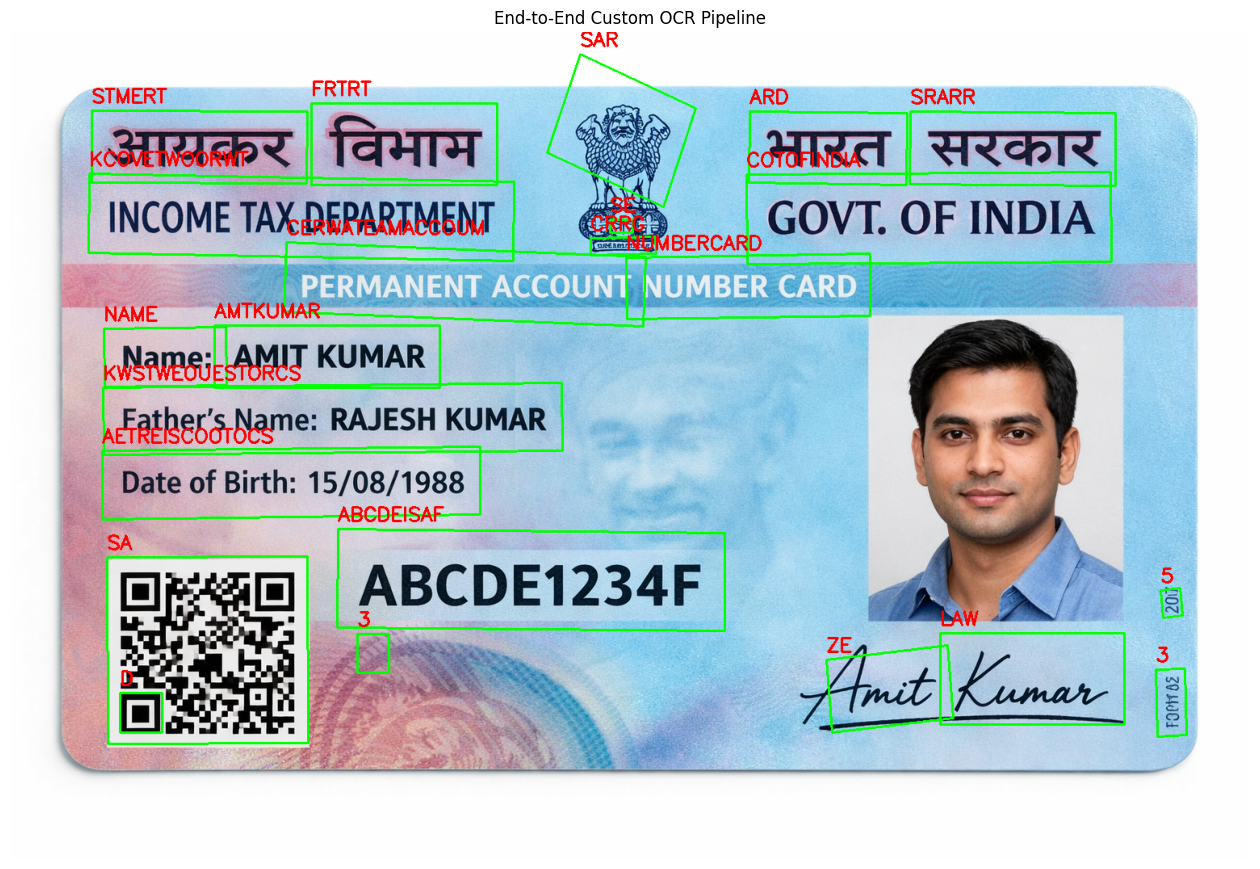

In [166]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models # <--- Add this line
import torch.nn.functional as F
import random
import torch.nn as nn
import pyclipper
from shapely.geometry import Polygon


# ---------------------------------------------------------
# 1. Critical Bridge: Perspective Crop & Resize
# ---------------------------------------------------------
def crop_and_warp(image, pts):
    """
    Takes the 4 corner points from DBNet and flattens the slanted text 
    into a perfectly straight rectangular image crop.
    """
    rect = np.zeros((4, 2), dtype="float32")
    rect[:] = pts
    (tl, tr, br, bl) = rect

    # Calculate max width
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    # Calculate max height
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    # Construct target destination points
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    # Calculate the perspective transform matrix and warp
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    
    return warped

def resize_and_pad(img_pil, target_w=256, target_h=32):
    """Preserves aspect ratio to prevent CRNN distortion."""
    w, h = img_pil.size
    new_w = int(w * (target_h / h))
    new_w = min(new_w, target_w)
    
    img_resized = img_pil.resize((new_w, target_h), Image.Resampling.LANCZOS)
    target_img = Image.new('L', (target_w, target_h), color=0)
    target_img.paste(img_resized, (0, 0))
    return target_img

# ---------------------------------------------------------
# 2. Unified Inference Logic
# ---------------------------------------------------------
def pipeline_end_to_end(image_path, dbnet_model, crnn_model, device):
    print(f"\nProcessing: {image_path}")
    
    # 1. Load Image
    orig_image = cv2.imread(image_path)
    if orig_image is None:
        raise FileNotFoundError("Image not found!")
        
    orig_rgb = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)
    orig_shape = orig_rgb.shape[:2]
    
    # Prepare for DBNet (Resize to standard 1280x720 or 640x640)
    target_size = (1920, 1080)
    resized_image = cv2.resize(orig_rgb, target_size)
    
    img_tensor = torch.from_numpy(resized_image).float().permute(2, 0, 1) / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = (img_tensor - mean) / std
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # 2. Run Detector (DBNet)
    dbnet_model.eval()
    with torch.no_grad():
        db_outputs = dbnet_model(img_tensor)
        prob_map = db_outputs['prob_map']
        
    post_processor = DBPostProcess(prob_threshold=0.5, unclip_ratio=1.2)
    detected_boxes = post_processor(prob_map, orig_shape, (target_size[1], target_size[0]))
    
    # 3. Process Each Box with CRNN
    crnn_model.eval()
    crnn_transform = transforms.Compose([
        transforms.Resize((32, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    final_results = []
    vis_image = orig_rgb.copy()
    
    # Sort boxes top-to-bottom for readable output
    detected_boxes = sorted(detected_boxes, key=lambda box: np.min(box[:, 1]))
    
    
    for i, box in enumerate(detected_boxes):
        # A. Warp & Crop the slanted text perfectly flat
        crop_bgr = crop_and_warp(orig_image, box)
        if crop_bgr.size == 0 or crop_bgr.shape[0] == 0 or crop_bgr.shape[1] == 0:
            continue
            
        # B. Prepare for CRNN (Grayscale -> Pad)
        # B. Prepare for CRNN (Grayscale -> PIL)
        crop_gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
        crop_pil = Image.fromarray(crop_gray)
        
        # REMOVED resize_and_pad. Let the transform stretch it!
        crnn_tensor = crnn_transform(crop_pil).unsqueeze(0).to(device)
        
        # C. Recognize
        with torch.no_grad():
            logits = crnn_model(crnn_tensor)
            raw_pred = decode_batch(logits)[0]
            
        final_results.append({"box": box, "text": raw_pred})
        
        # D. Visualize
        cv2.polylines(vis_image, [box.astype(int)], isClosed=True, color=(0, 255, 0), thickness=2)
        # Put text just above the top-left corner of the box
        top_left = tuple(box[0].astype(int))
        cv2.putText(vis_image, raw_pred, (top_left[0], top_left[1] - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
                    
        print(f"[{i:02d}] Detected: '{raw_pred}'")

    # 4. Show Final Image
    plt.figure(figsize=(16, 12))
    plt.imshow(vis_image)
    plt.title("End-to-End Custom OCR Pipeline")
    plt.axis("off")
    plt.show()
    
    return final_results

# ---------------------------------------------------------
# 3. Execution
# ---------------------------------------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize Models (Ensure NUM_CLASSES and idx_to_char are defined from your CRNN setup)
    dbnet = DBNet(pretrained_backbone=False).to(device)
    dbnet.load_state_dict(torch.load("/Users/pashantraj/Desktop/Repos/Computer_vision/DBNet/dbnet_icdar_best.pth", map_location=device))
    
    crnn = CRNN(num_classes=NUM_CLASSES).to(device)
    crnn.load_state_dict(torch.load("/Users/pashantraj/Desktop/Repos/Computer_vision/CRNN/crnn_trained.pth", map_location=device))
    
    # Run!
    test_image_path = "/Users/pashantraj/Desktop/jmr/pan.png" 
    
    results = pipeline_end_to_end(test_image_path, dbnet, crnn, device)